In [1]:
from background_db import *
import matplotlib.pyplot as plt

# Make background DB

BkgList(PSD, 28 bands)
  Energy range: 18.25 - 1999.75 keV
  Energy bins: 3964 (coverage: 3093/3964)
  Detectors: 19
  Bin size: 0.5 keV
BkgEband(PSD, cls_plaw_function)
  File: com_spec_params_e453_490_revidx_0043-2043.pkl
  Param table shape: (2, 42, 19, 2)
  Energy range: 453.75 - 490.25 keV
  Bin size: 0.5 keV
  Timescale: rev


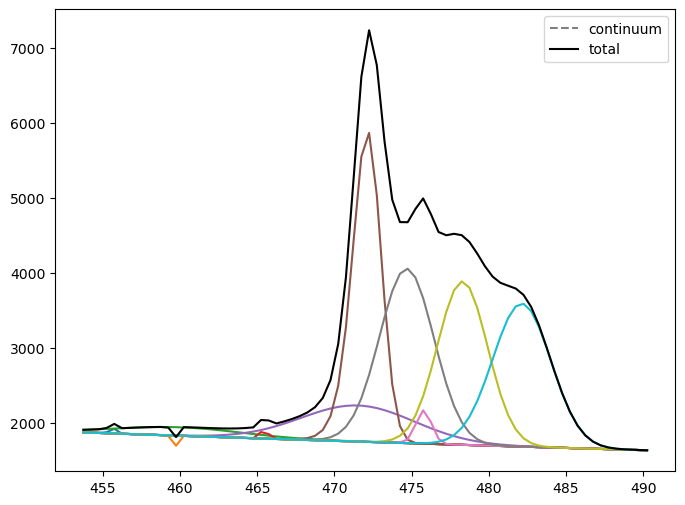

BkgEband(PSD, cls_plaw_function)
  File: com_spec_params_e490_530_revidx_0043-2887.sav
  Param table shape: (2, 34, 19, 2594)
  Energy range: 490.25 - 529.75 keV
  Bin size: 0.5 keV
  Timescale: rev


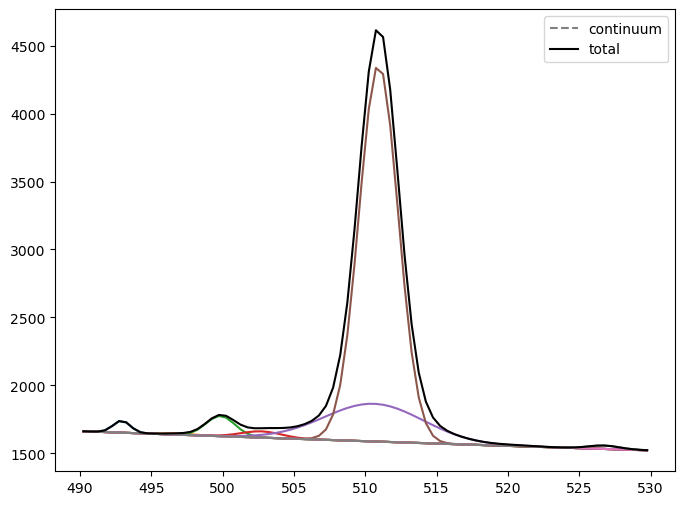

In [4]:
# spec_param_dir = '/data1/ipp_afs_mirror/integral/data/databases/spi_line_db/data/save/0043-2877'
evt_type='PSD'
spec_param_dir= f'/Users/tbastro/SPI_analysis/BACKGROUND/BG_SAV/{evt_type}/'
bkg_full = BkgList(spec_param_dir, evt_type=evt_type)
print(bkg_full)

# for ndet in range(3):
ndet=0
for bkg in bkg_full.bkg_range_list[0:2]:
    print(bkg)
    ax=bkg.calc_spec_pid_det_eband(pid=43, det=ndet, E=None, plot=True)
    plt.show()

In [27]:
bkg.params_table[:,:,0,50]

array([[ 8.88593755e+02, -2.37736525e+00,  2.87011598e+01,
         4.55542074e+02,  1.11239090e+00,  1.07183379e-01,
         5.39550679e+00,  4.60237968e+02,  8.29088026e-01,
         3.27459924e-01,  7.64511283e+01,  4.63221851e+02,
         1.06314061e+00,  5.99696120e-02,  3.48638040e+00,
         4.65747241e+02,  1.40230429e+00,  1.80685777e-01,
         1.34132512e+02,  4.68670543e+02,  2.16357915e+00,
         4.24390674e-01,  1.95301200e+03,  4.72231538e+02,
         8.31551900e-01,  6.37786742e-01,  5.92574091e+02,
         4.73884294e+02,  8.09381621e-01,  1.34120220e-01,
         1.07156372e+03,  4.75029180e+02,  2.14798881e+00,
         1.64801250e-01,  9.25363901e+02,  4.78371150e+02,
         2.27702068e+00,  3.26141296e-01,  8.31203882e+02,
         4.82508443e+02,  2.20625687e+00,  3.39412704e-01],
       [ 7.15833517e+00,  9.06199754e-02,  1.17963676e+01,
         9.54621439e-02,  7.39343991e-02,  6.22128453e-02,
         3.62643942e+00,  2.10627123e-01,  2.33355838e-

## all energy range

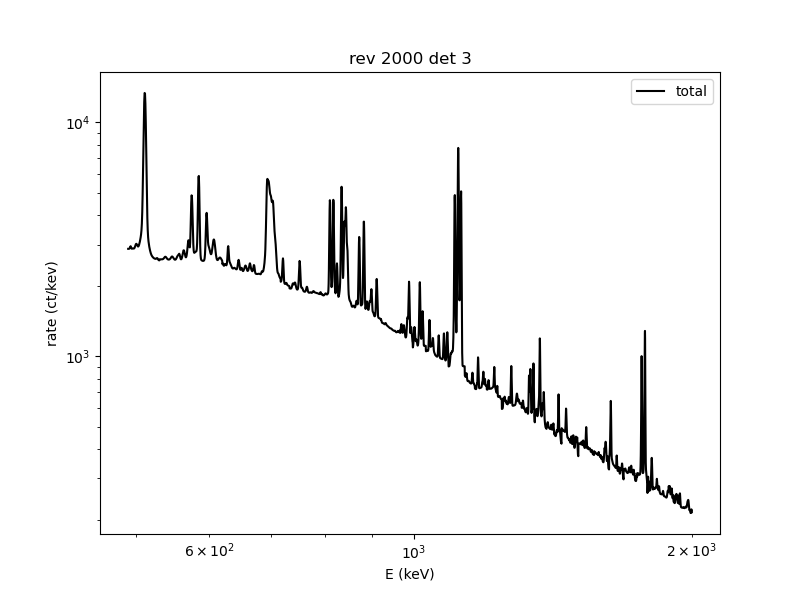

In [5]:
%matplotlib widget
det=3
pid=2000
ax=bkg_full.calc_spec_pid_det(pid=pid, det=det, plot=True)

plt.show()

In [12]:
bkg_full.get_available_pid_list()

array([  43,   44,   45, ..., 2885, 2886, 2887],
      shape=(2596,), dtype=int32)

In [13]:
pid_list=np.arange(40, 50, dtype='int64')
# pid_list=np.arange(1, 5, dtype='int64')
bkg_full.write_fits_files(bkg_db_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB', pid_list=pid_list, compress=True)

  0%|          | 0/10 [00:00<?, ?it/s]

No background for rev 40.
No background for rev 41.
No background for rev 42.


100%|██████████| 10/10 [00:01<00:00,  6.67it/s]

background successfully written in /Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB/SE


# Create scw background

In [1]:
from obs_background import *

loading scw info
load energy bounds
loading observation live times
Initialize data base meta
Initialize revolution backgrounds from data base
Calculating background for 64 pointings, 19 detectors
calc_bkg took 0.001s
Available background types: ['CONTINUUM', 'LINES']
Shape of first background type: (1216, 41, 2)


<Axes: title={'center': 'Background (scw 0, det 0)'}, xlabel='Energy (keV)', ylabel='Counts'>

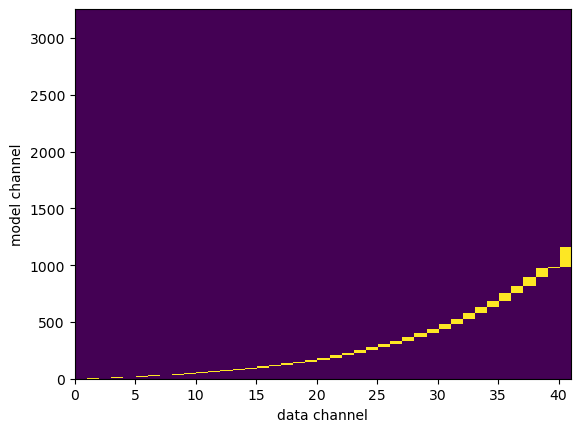

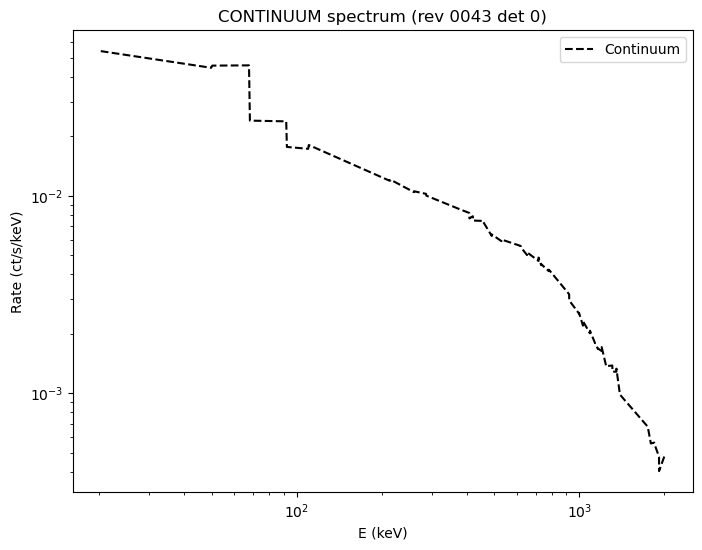

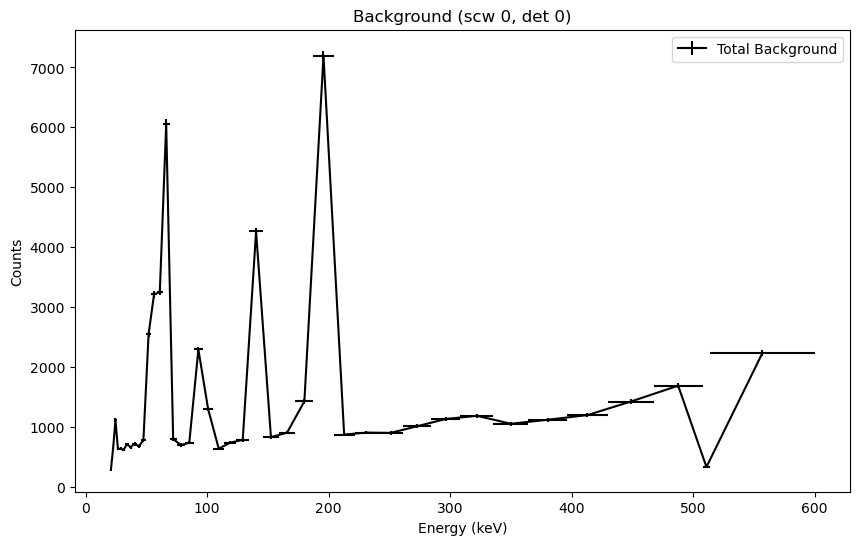

In [2]:
# %matplotlib widget
evt_type='SE'
main_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/crab_dir_test'
bkg_db_dir = '/Users/tbastro/SPI_analysis/BACKGROUND/BKG_DB'
obs_bkg = ObsBkg(main_dir, evt_type)
livetime = LiveTimeRev(bkg_db_dir+'/det_livetime_rev.fits',evt_type)
obs_bkg.normalize_tracer(livetime)
obs_bkg.init_rev_bkg_list(livetime_rev=livetime, bkg_db_dir=bkg_db_dir)
obs_bkg.bkg_rev_list[0].plot_rbn_mat()
obs_bkg.bkg_rev_list[0].plot(det=0)

bkg_dict = obs_bkg.calc_bkg()
print("Available background types:", list(bkg_dict.keys()))
print("Shape of first background type:", bkg_dict[list(bkg_dict.keys())[0]].shape)
obs_bkg.plot_bkg(scw_idx=0, det=0, bkg_types=None, type_spec='counts')

In [3]:
obs_bkg.write_output_bkg('./output_test')

Creating output dir: ./output_test
Writting CONTINUUM...
Written ./output_test/output_bgmodel-conti.fits.gz
Writting LINES...
Written ./output_test/output_bgmodel-lines.fits.gz
Written ./output_test/output_bgmodel_conti_sep_idx.fits.gz
write_output_bkg took 0.132s


## per detector

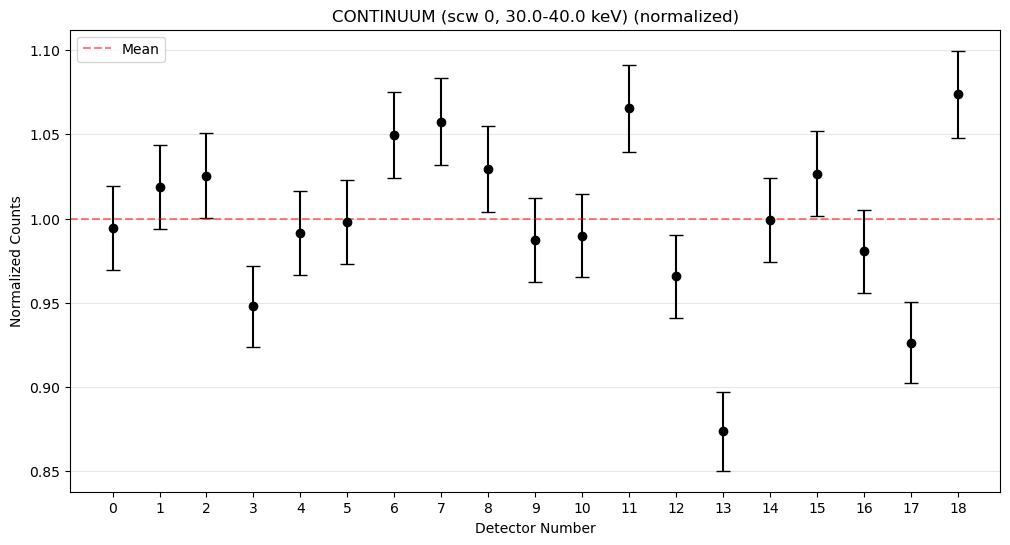

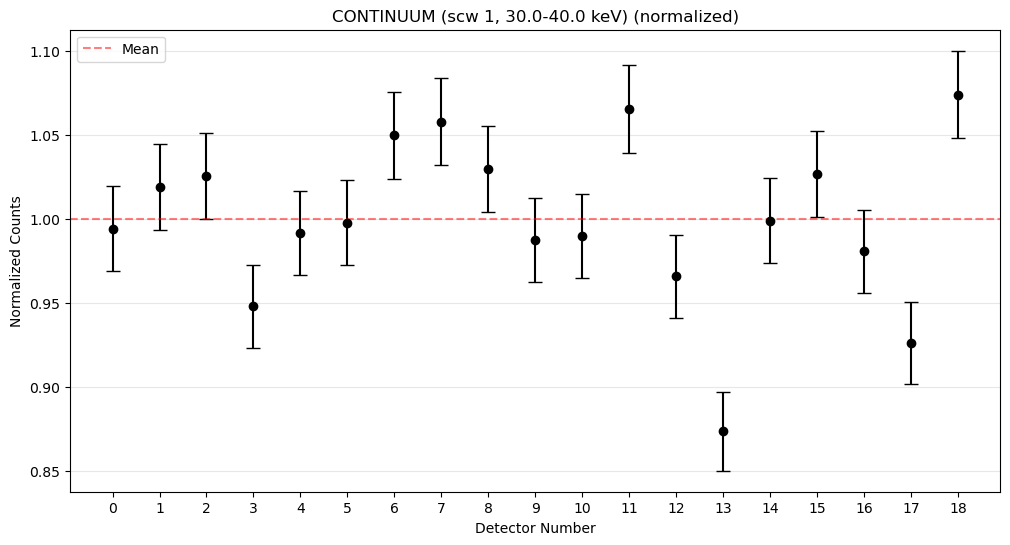

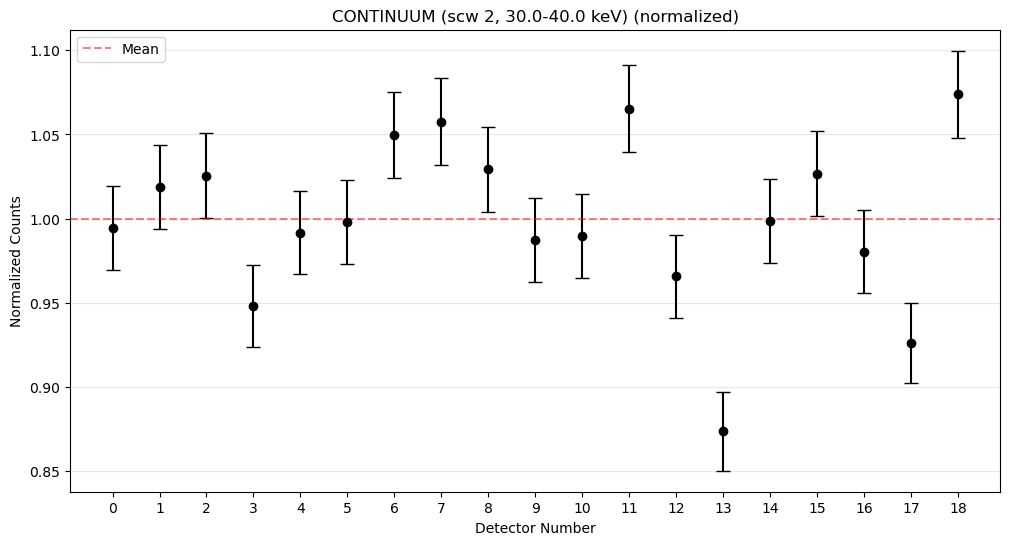

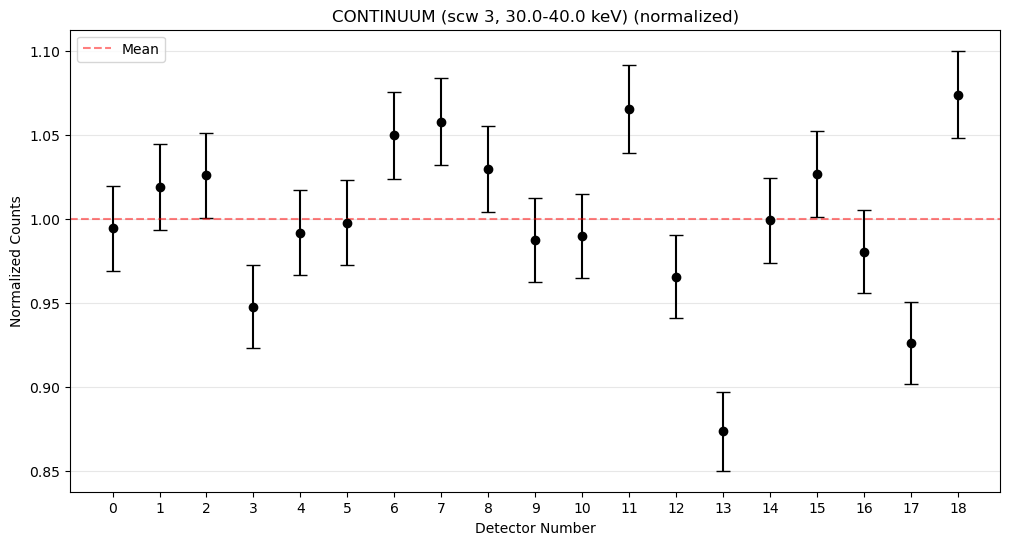

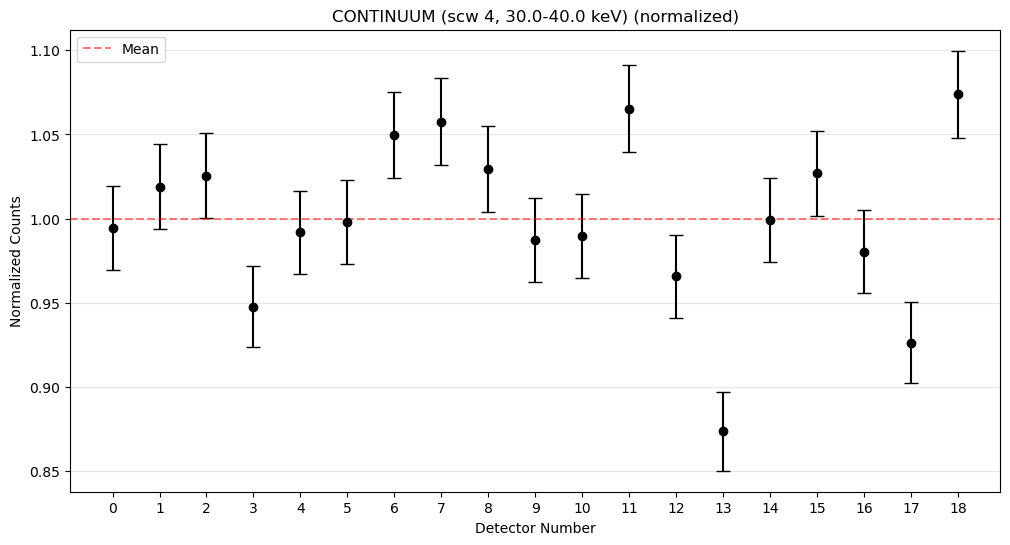

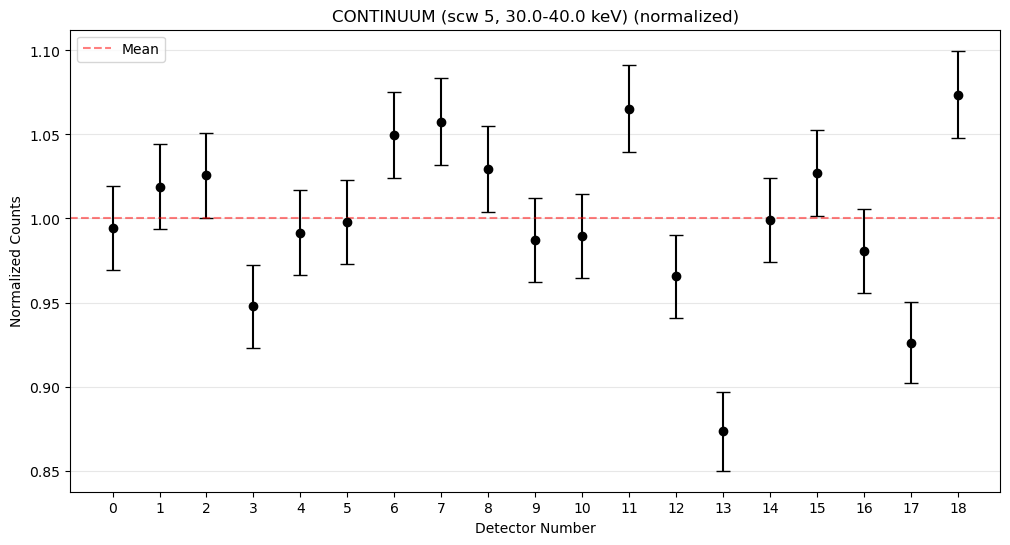

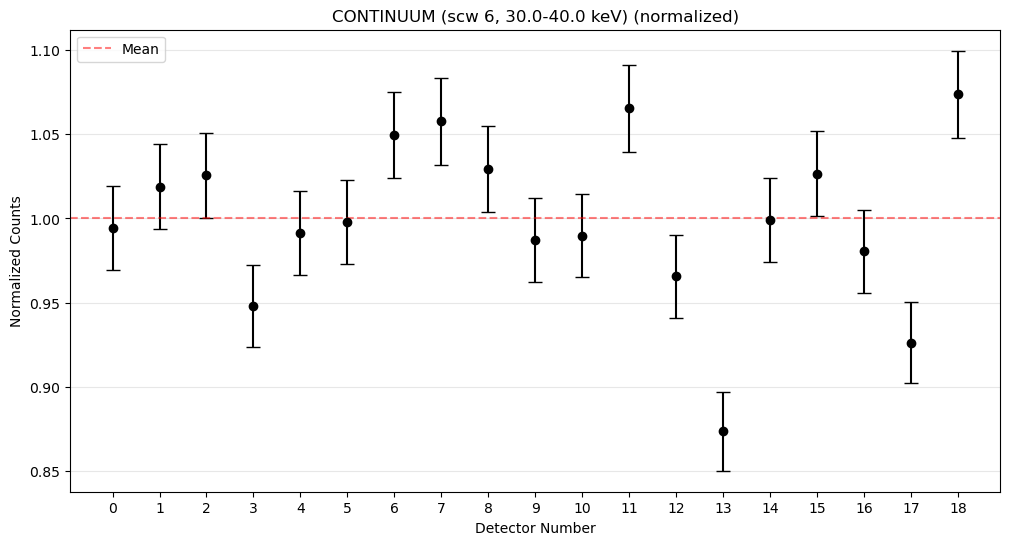

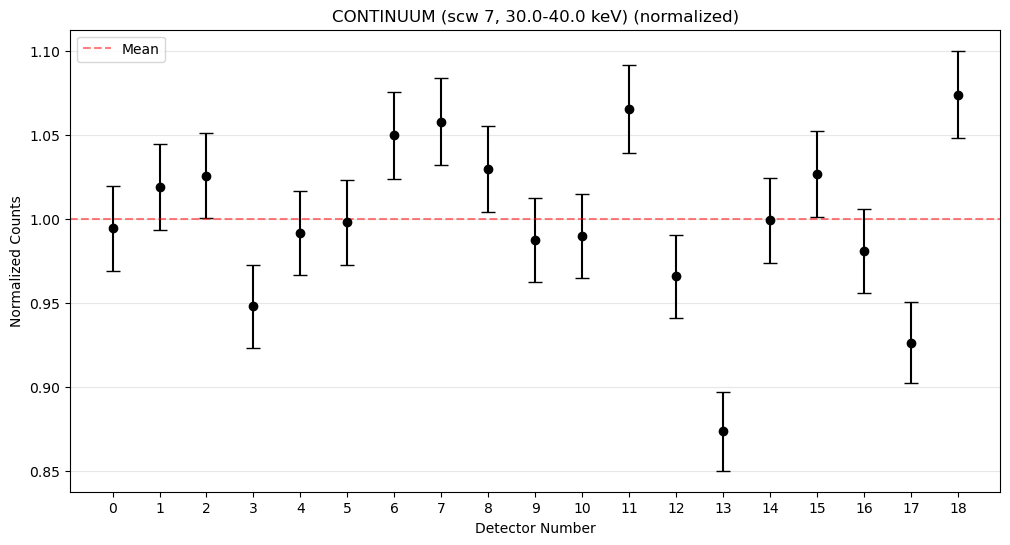

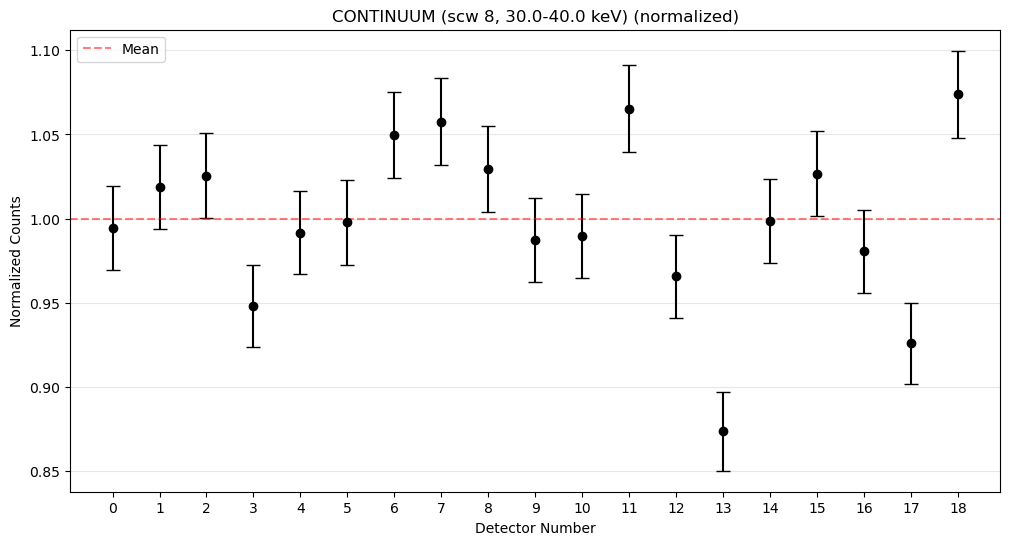

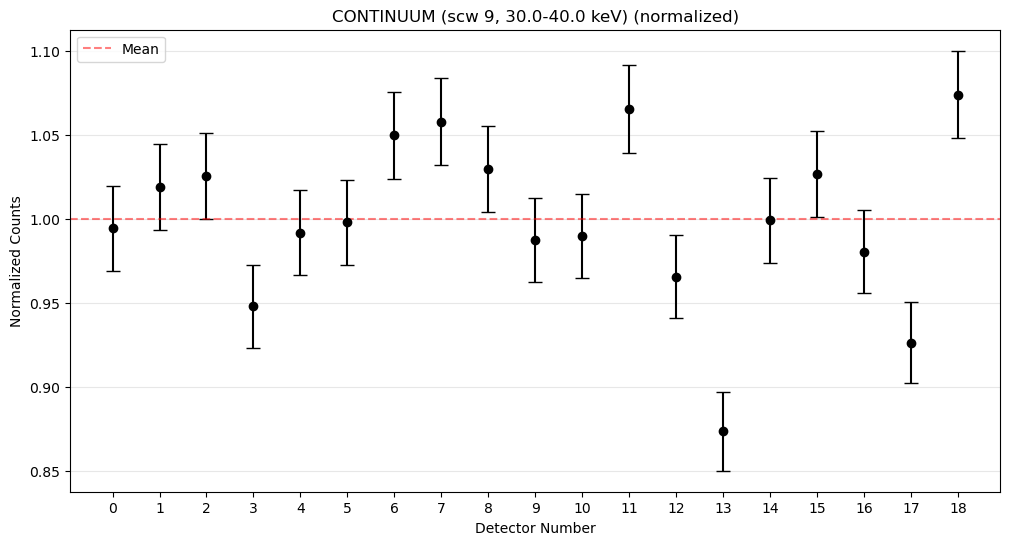

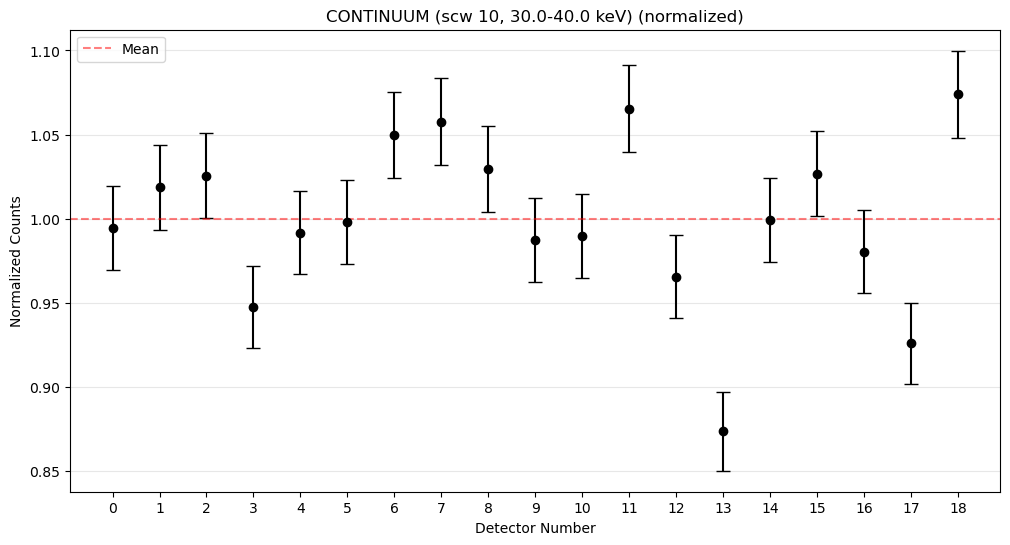

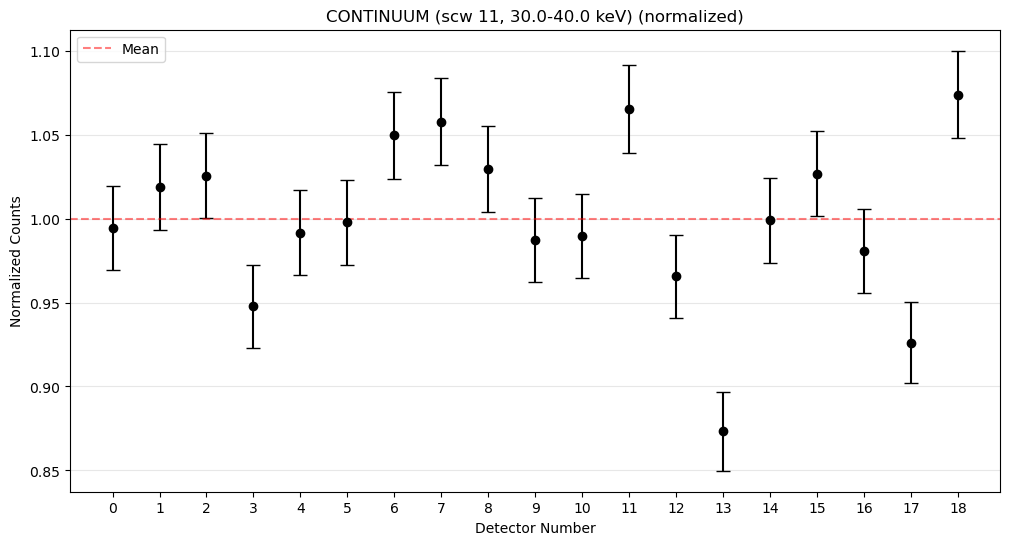

In [4]:
for scw_idx in range(12):
    # ax=obs_bkg.plot_bkg_by_detector(scw_idx, 30, 40, None, normalize=True)
    ax=obs_bkg.plot_bkg_by_detector(scw_idx, 30, 40, 'CONTINUUM', normalize=True)
    # ax.set_ylim(.8, .88)
    plt.show()

## comparison

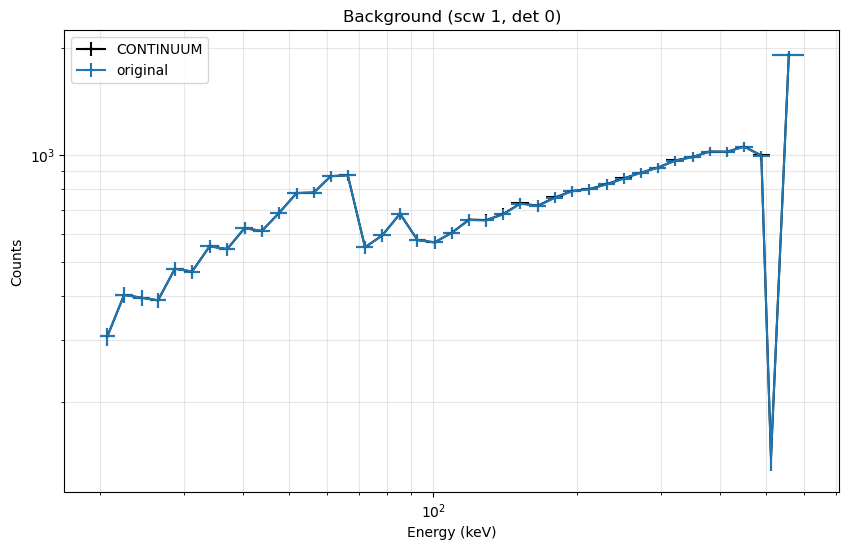

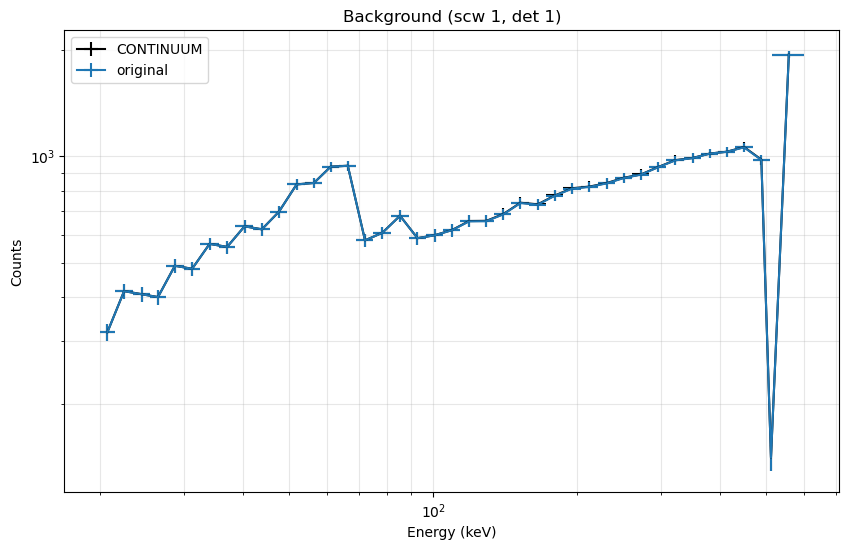

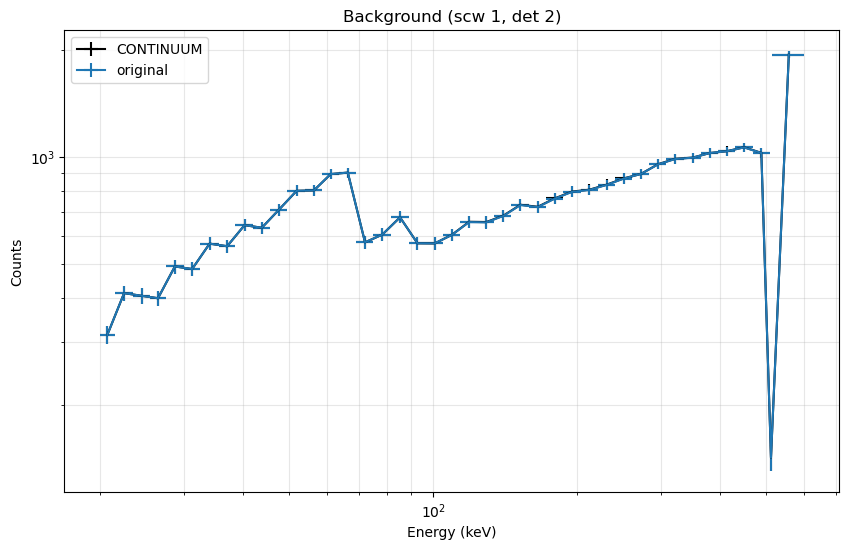

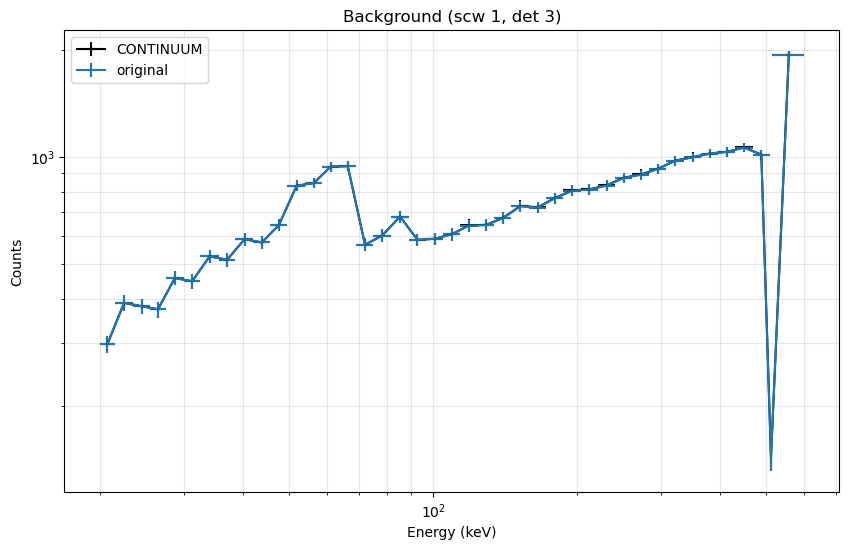

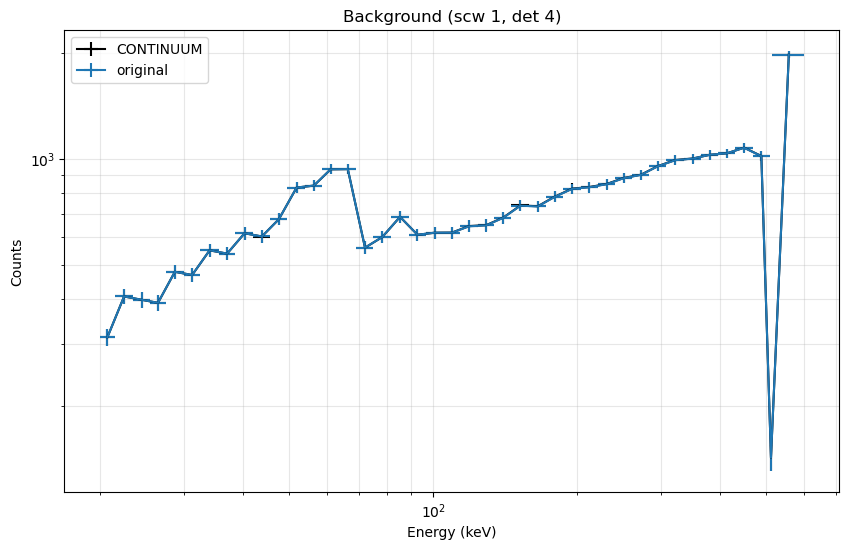

In [5]:
# %matplotlib widget
def check_output(dir='background_output/', file='output_bgmodel-conti.fits'):
    hdul=fits.open(dir+file)
    data=hdul[1].data
    return data

# out_dir='cookbook_dataset_02_0020-0600keV_SE/spi/bg-e0020-0600/' # old cookbook directory from 2013 
out_dir=f'/Users/tbastro/SPI_analysis/BACKGROUND/cookbook_dataset_02_0020-0600keV_SE_new/spi/bg-e0020-0600/' # fresh analysis from 2024
data_conti=check_output(dir=out_dir, file='output_bgmodel-conti.fits.gz')
data_sumlines=check_output(dir=out_dir, file='output_bgmodel-lines.fits.gz')
scw_idx = 1
bkg_type='CONTINUUM'
for det in range(5):
    # ax = obs_bkg.plot_bkg(scw_idx=det, det=scw_idx, bkg_types=[bkg_type], type_spec='counts') # reverse det/scw
    ax = obs_bkg.plot_bkg(scw_idx=scw_idx, det=det, bkg_types=[bkg_type], type_spec='counts')
    if bkg_type=='LINES':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_sumlines[scw_idx*19+det][0], yerr=data_sumlines[scw_idx*19+det][1],label='original')
        ax.set_xscale('log')
    elif bkg_type=='CONTINUUM':
        ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0], yerr=data_conti[scw_idx*19+det][1],label='original')
        ax.loglog()
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.show()

det 0 scw 6: ratio stderr 7.9e-04 (<1e-3)
det 1 scw 6: ratio stderr 7.8e-04 (<1e-3)
det 2 scw 6: ratio stderr 7.6e-04 (<1e-3)
det 3 scw 6: ratio stderr 7.3e-04 (<1e-3)
det 4 scw 6: ratio stderr 6.8e-04 (<1e-3)
det 5 scw 6: ratio stderr 7.1e-04 (<1e-3)
det 6 scw 6: ratio stderr 7.7e-04 (<1e-3)
det 7 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 8 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 9 scw 6: ratio stderr 8.4e-04 (<1e-3)
det 10 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 11 scw 6: ratio stderr 8.2e-04 (<1e-3)
det 12 scw 6: ratio stderr 8.4e-04 (<1e-3)
det 13 scw 6: ratio stderr 7.7e-04 (<1e-3)
det 14 scw 6: ratio stderr 8.2e-04 (<1e-3)
det 15 scw 6: ratio stderr 8.8e-04 (<1e-3)
det 16 scw 6: ratio stderr 8.5e-04 (<1e-3)
det 17 scw 6: ratio stderr 7.9e-04 (<1e-3)
det 18 scw 6: ratio stderr 8.9e-04 (<1e-3)


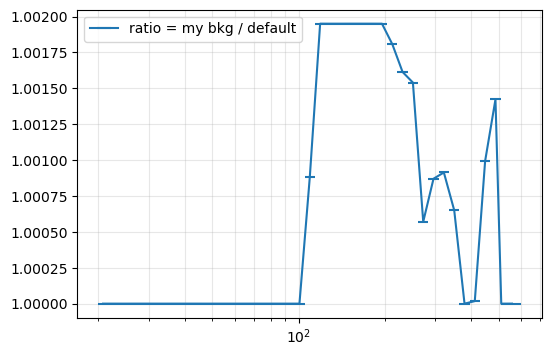

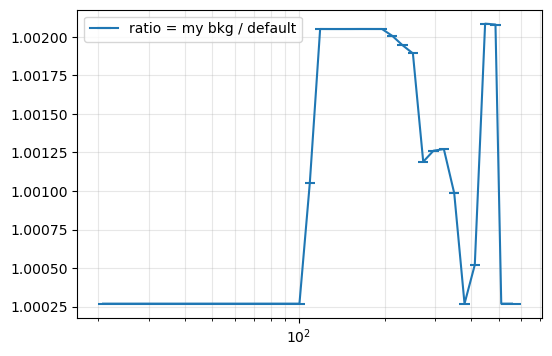

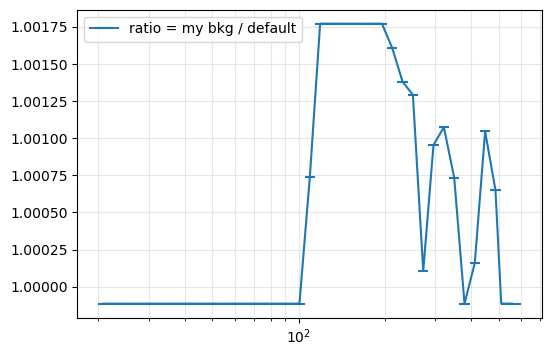

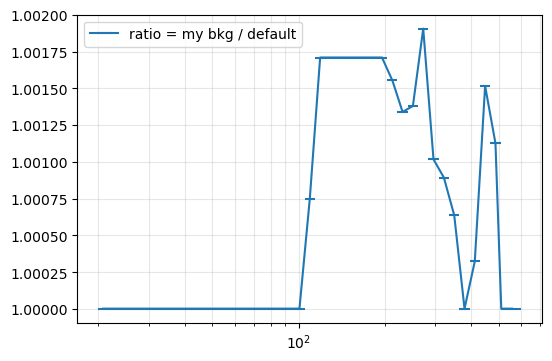

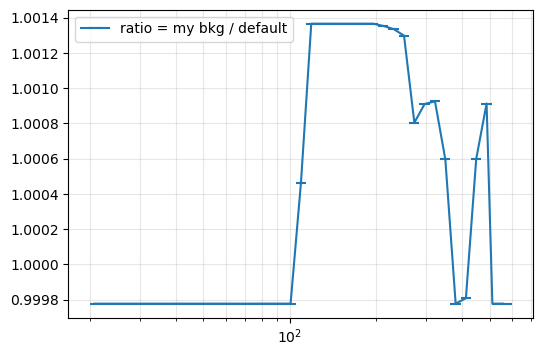

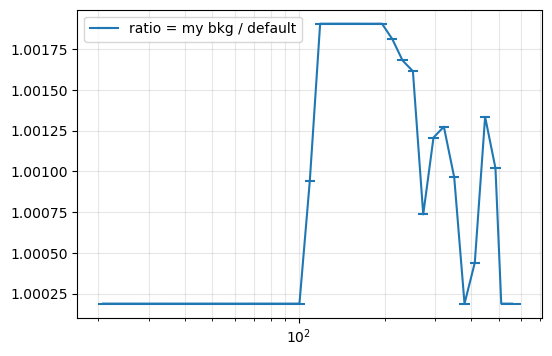

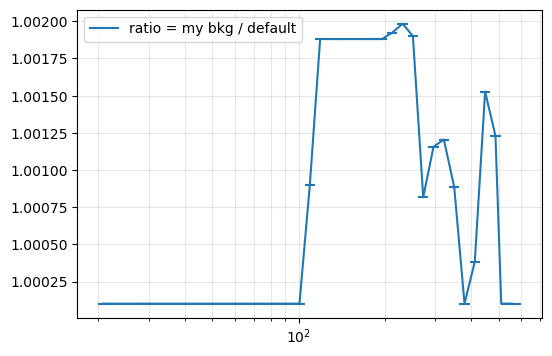

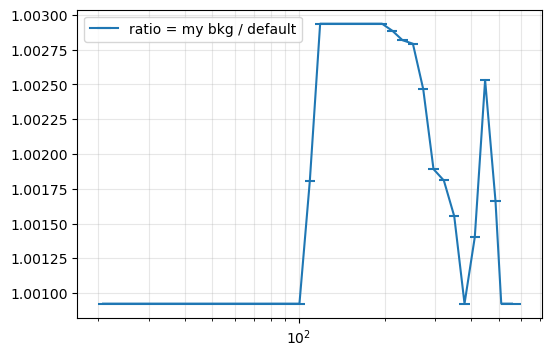

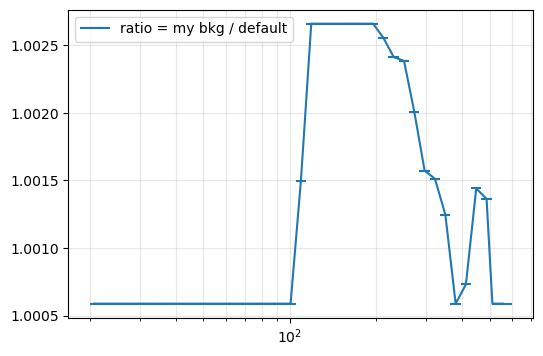

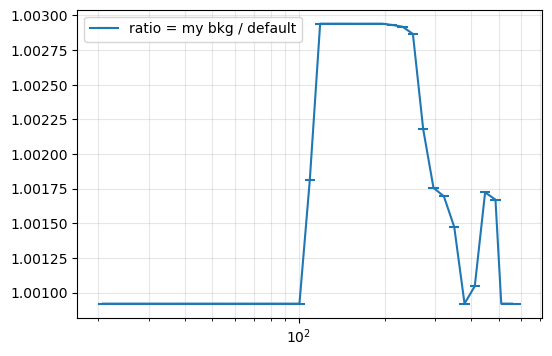

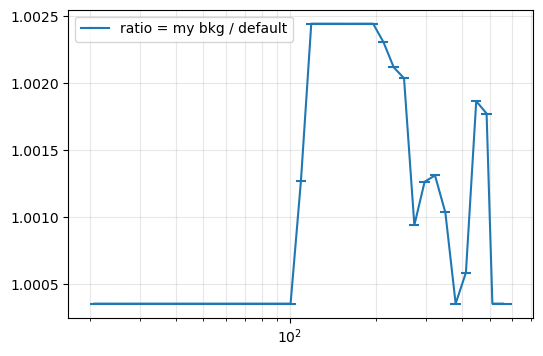

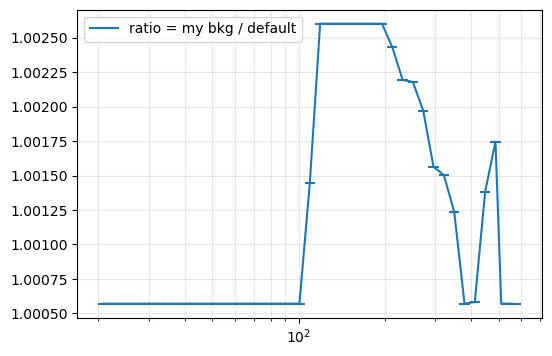

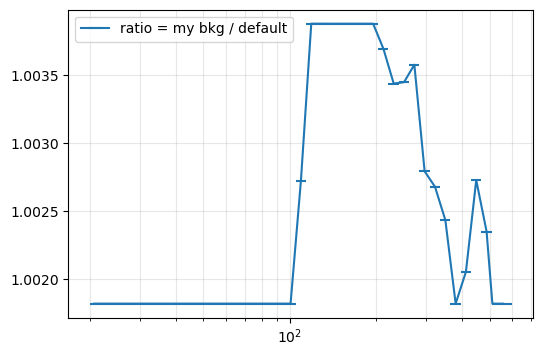

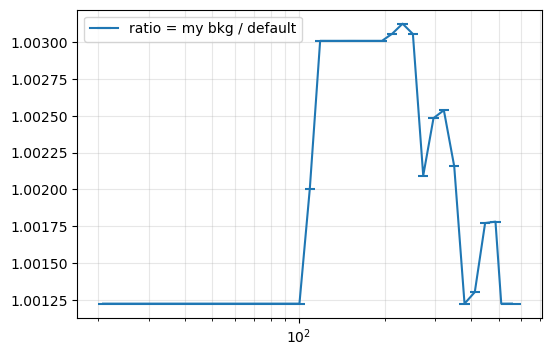

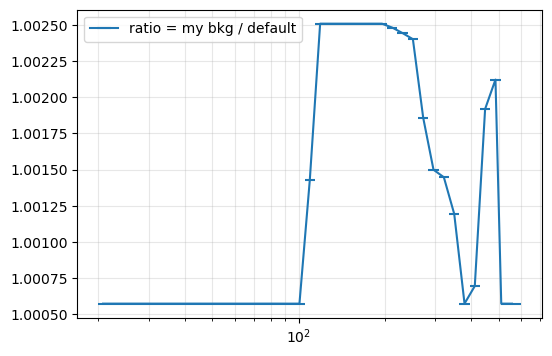

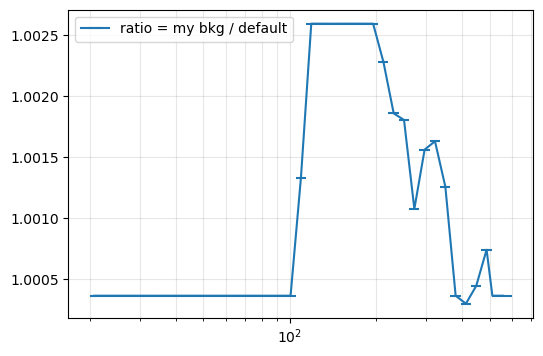

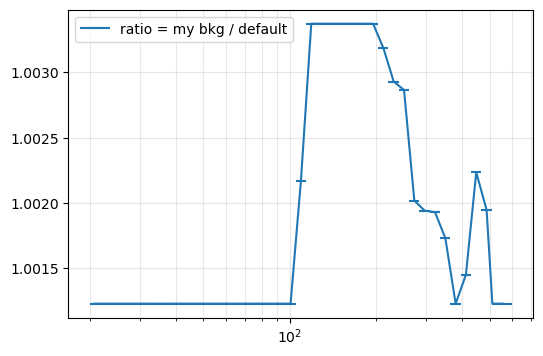

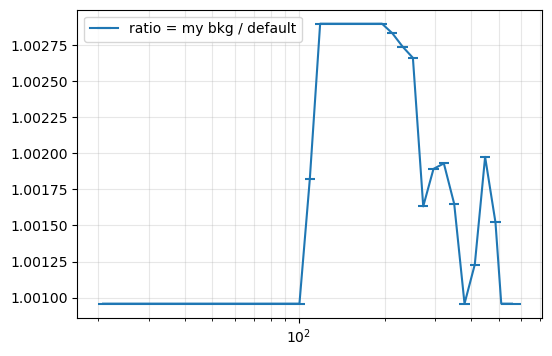

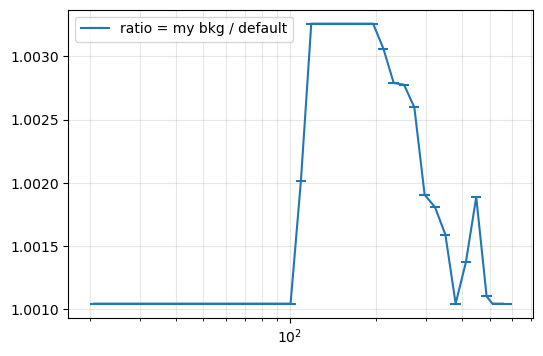

In [5]:
%matplotlib inline
scw_idx=6
for det in range(19):
    print(f'det {det} scw {scw_idx}: ', end='')
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx][:,0] / data_conti[scw_idx*19+det][0]
    # ratio=obs_bkg.bkg_output_dico['LINES'][det + obs_bkg.det_num * scw_idx] / data_sumlines[scw_idx*19+det][0]
    print(f'ratio stderr {ratio.std():.1e}'+int(ratio.std()<1e-3)*' (<1e-3)')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=ratio,label='ratio = my bkg / default')
    # ratio=obs_bkg.bkg_output_dico['CONTINUUM'][det + obs_bkg.det_num * scw_idx] / data[scw_idx*19+det][0]
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    # plt.show()

## raw spectrum

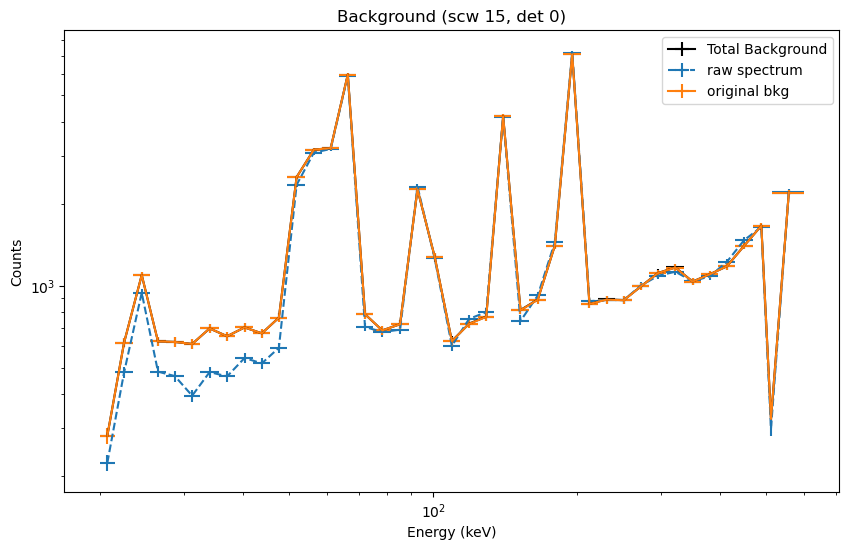

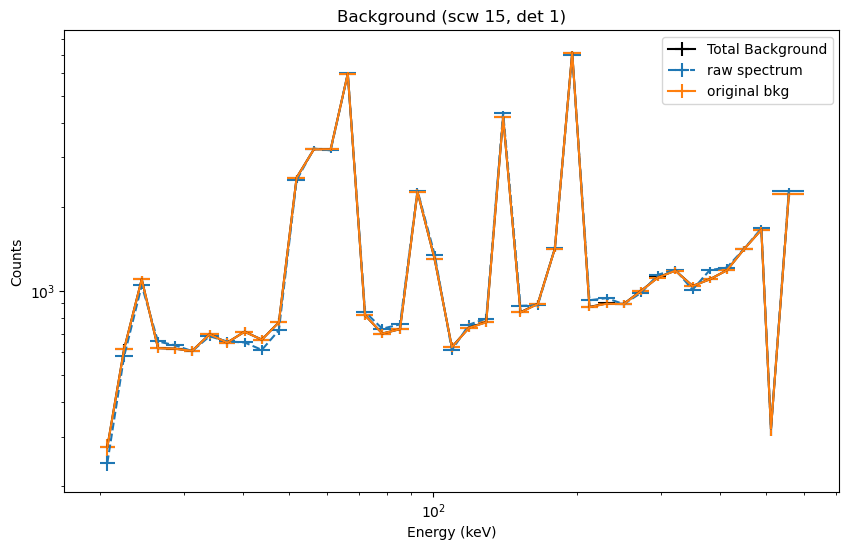

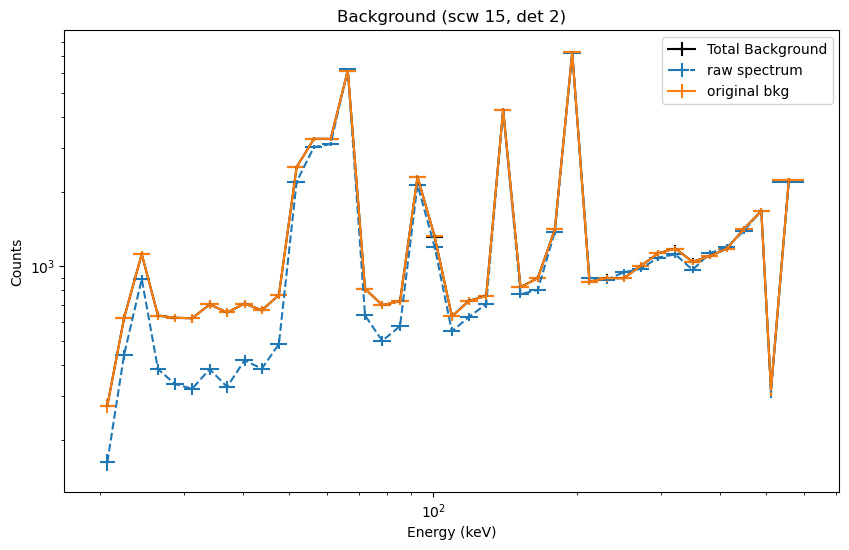

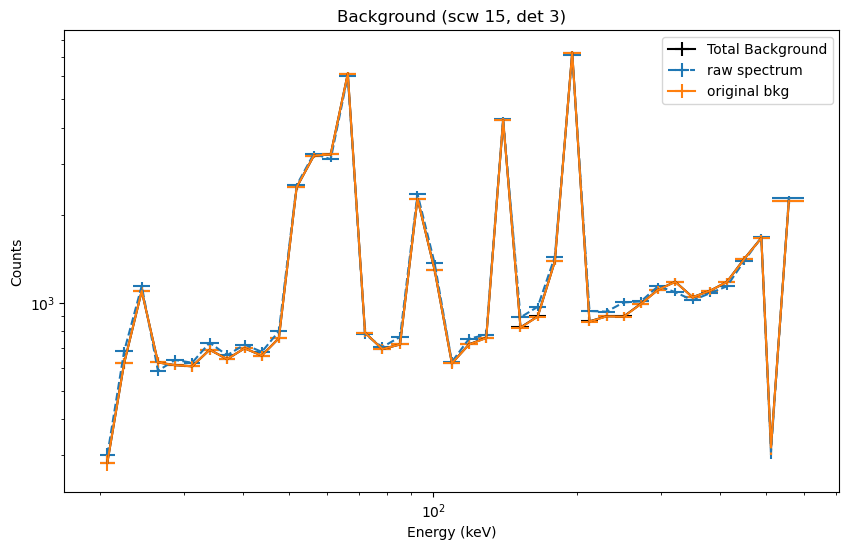

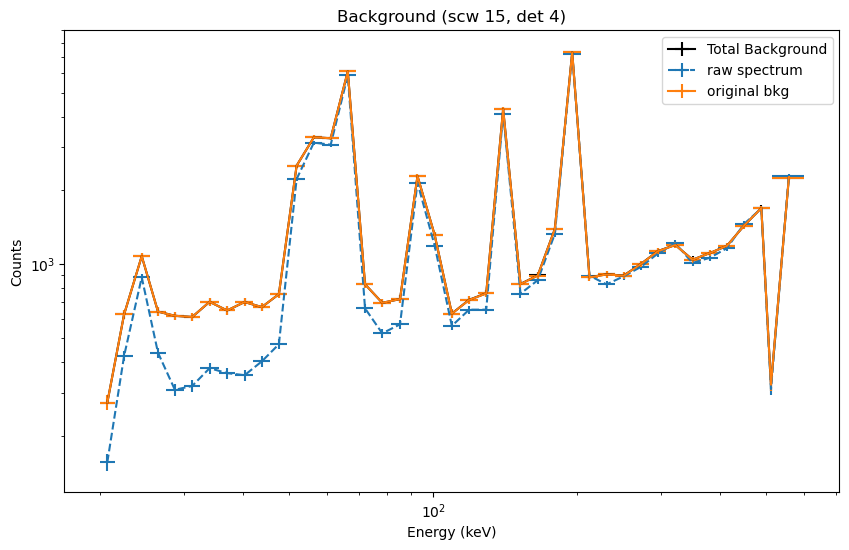

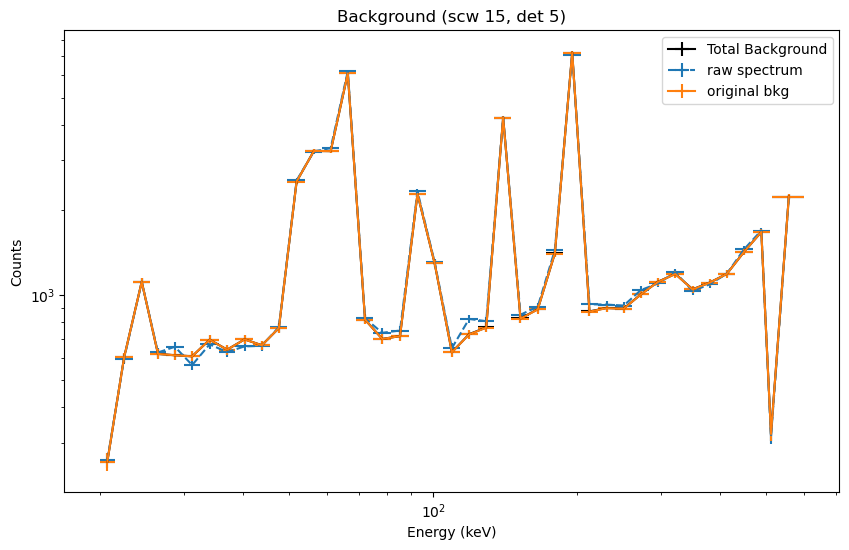

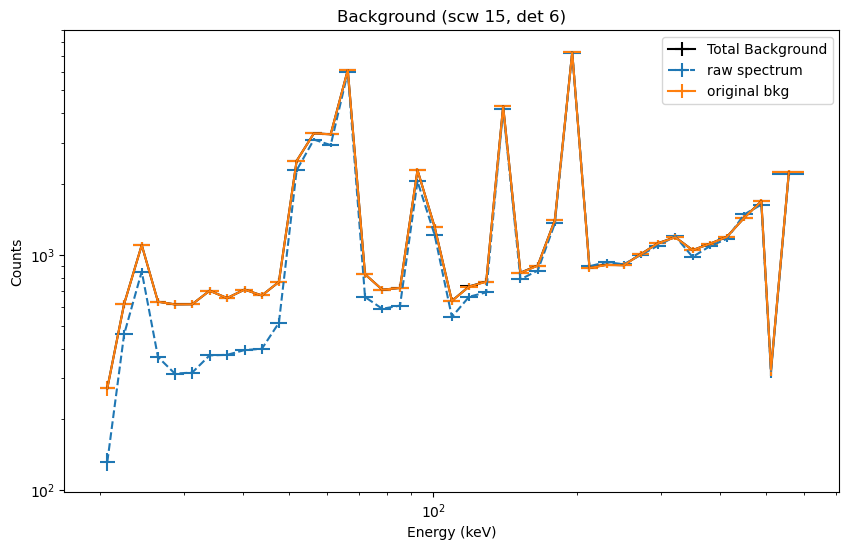

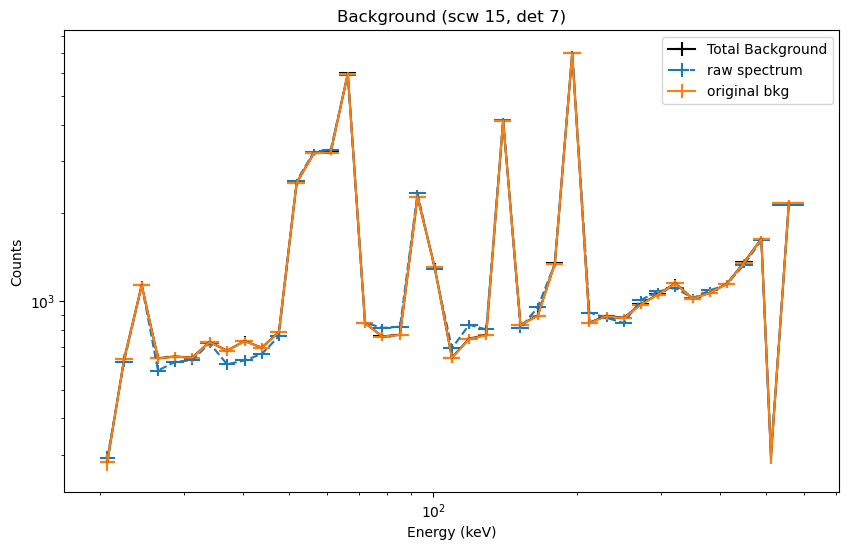

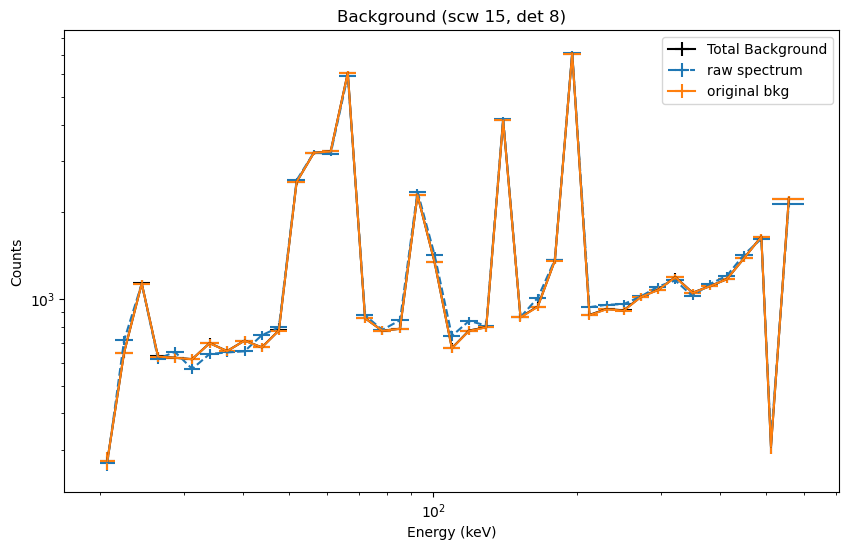

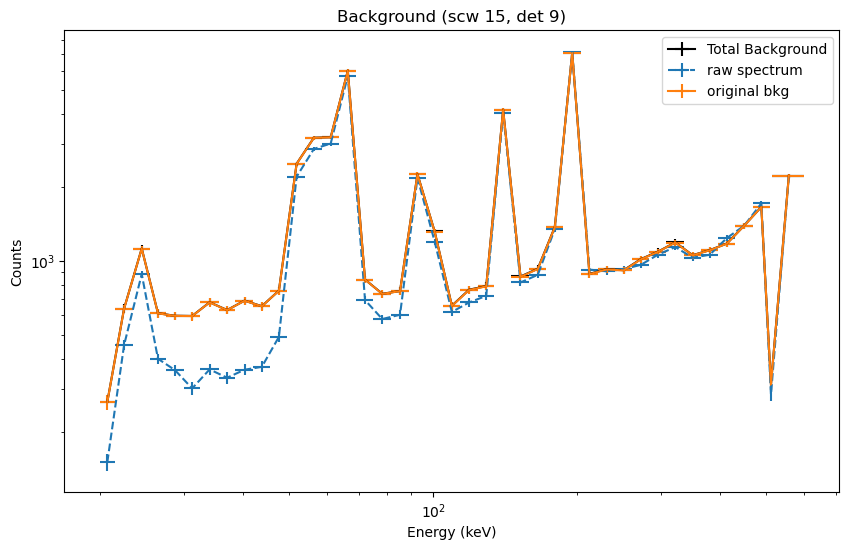

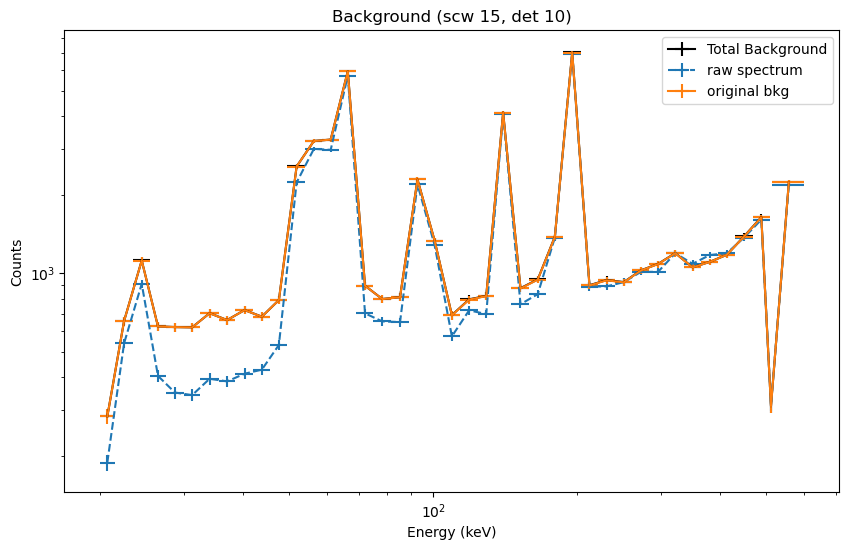

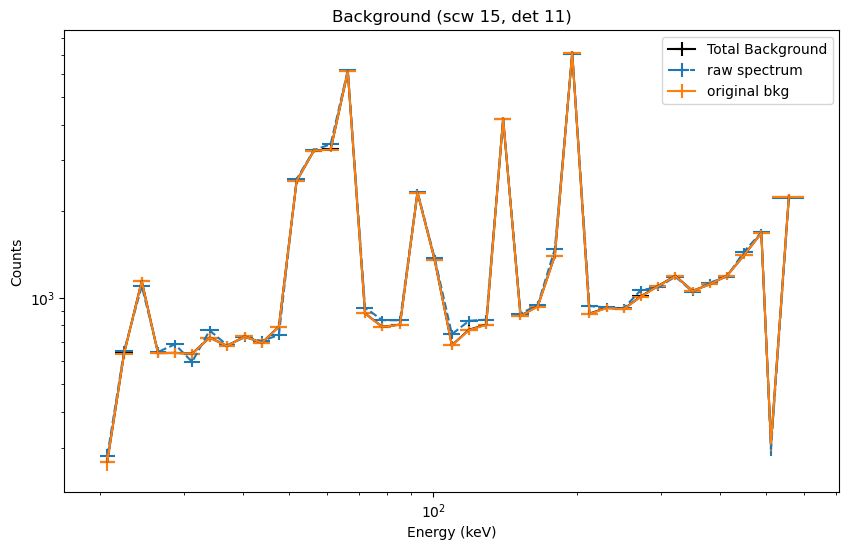

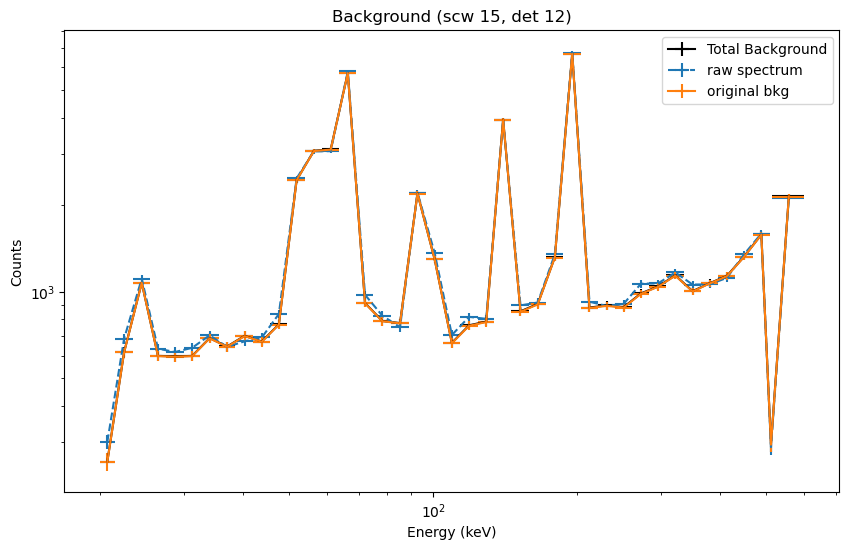

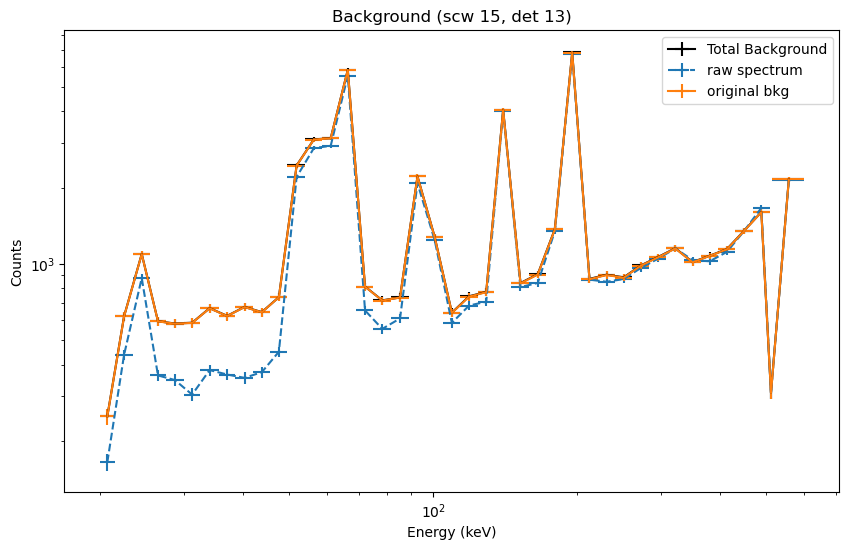

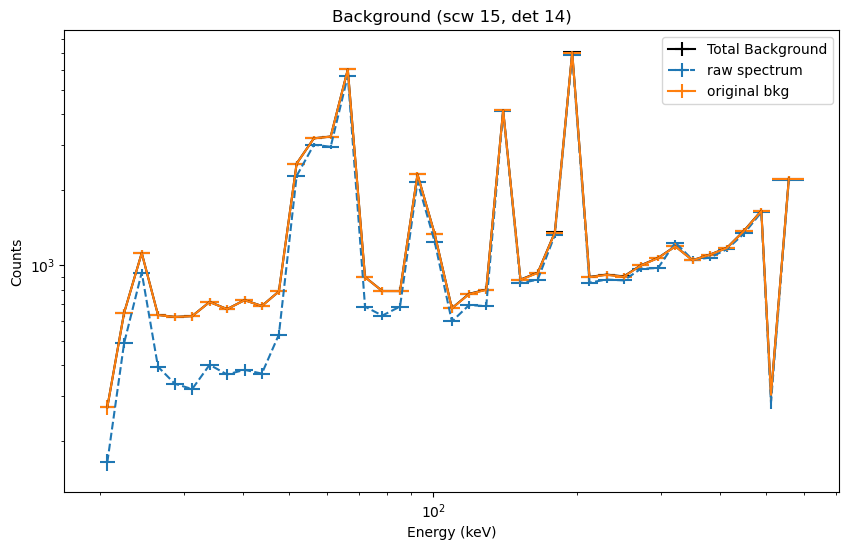

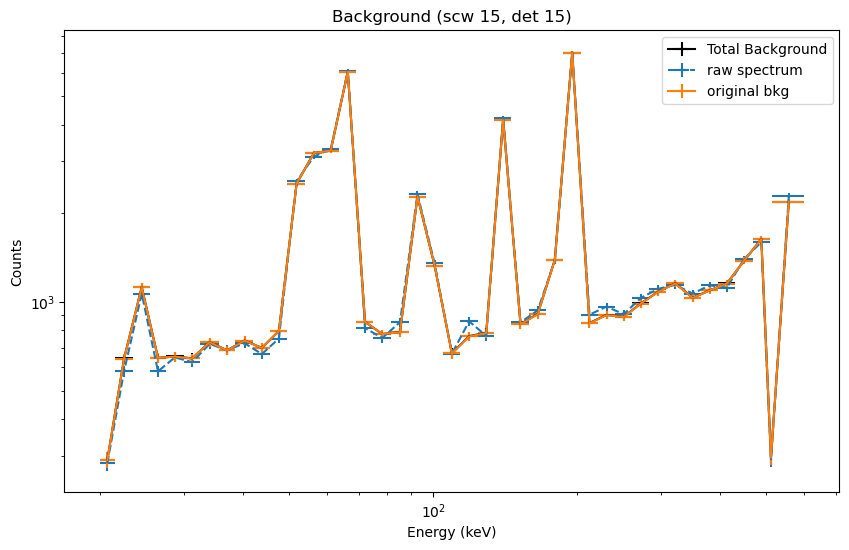

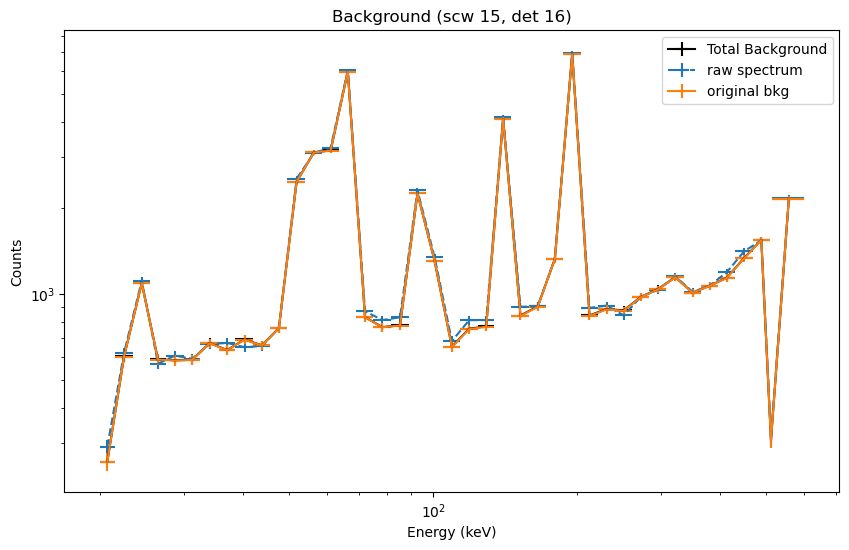

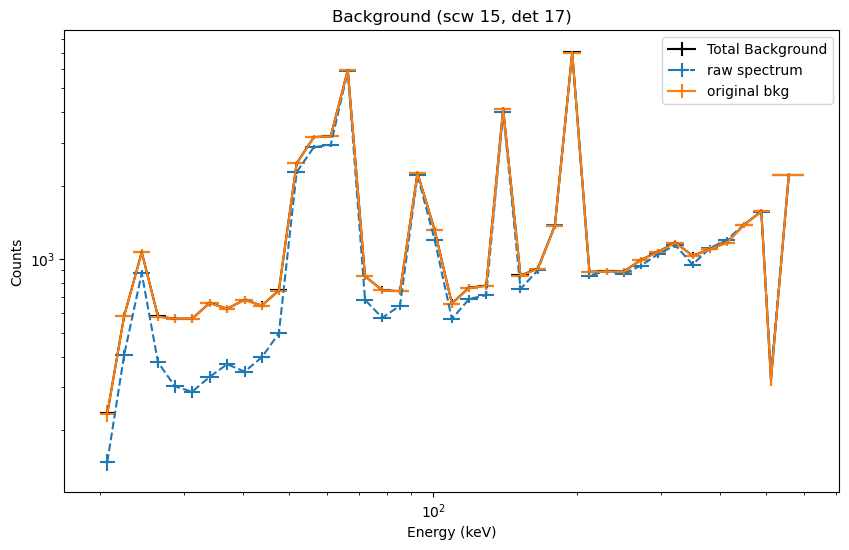

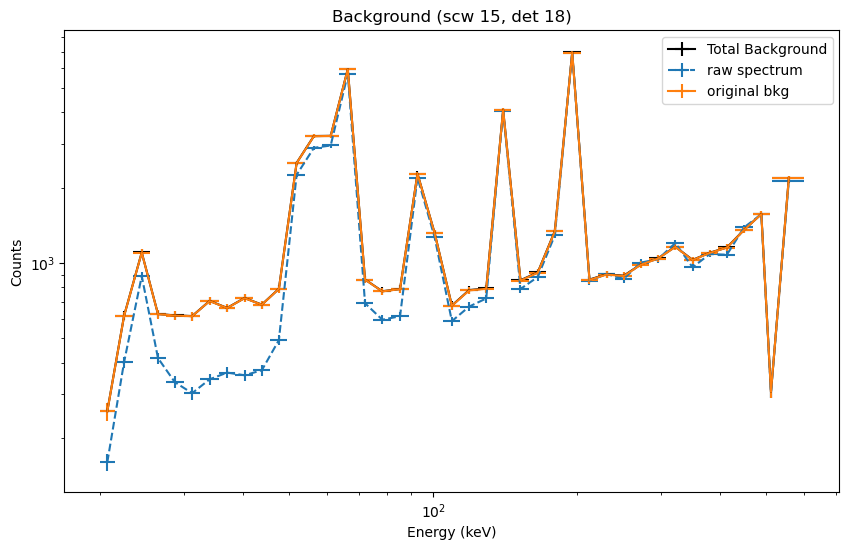

In [6]:
evts_name = f'{main_dir}/spi/evts_det_spec.fits.gz'
# poin_name = [strtrim(string('/pointing.fits.gz'),1),strtrim(string('/pointings.fits.gz'),1)]
# e_lo, e_hi = 30, 350 # kev
# SE_range =  18.25 + np.arange(3964) * 0.5
# E_idx_mask = (SE_range>e_lo) & (SE_range<e_hi)
scw_raw_spec = fits.open(evts_name)[1].data
scw_idx = 15
for det in range(19):
    # fig, ax=plt.subplots(1,1)
    ax=obs_bkg.plot_bkg(scw_idx,det,bkg_types=None)
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y=scw_raw_spec[scw_idx*19+det][0], yerr=scw_raw_spec[scw_idx*19+det][1],ls='--', label='raw spectrum')
    ax.errorbar(obs_bkg.E_center, xerr=obs_bkg.E_width/2, y= data_conti[scw_idx*19+det][0]+data_sumlines[scw_idx*19+det][0],
                yerr=np.sqrt(data_conti[scw_idx*19+det][1]**2+data_sumlines[scw_idx*19+det][1]**2),label='original bkg')
    # ax.errorbar( bkg_spectrum, yerr=np.sqrt(bkg_spectrum), fmt='k-', label=label)
    ax.set_xlabel('Energy (keV)')
    ax.legend()
    ax.loglog()
    plt.show()

## spi init 

(0.0, 130.66239301330228)

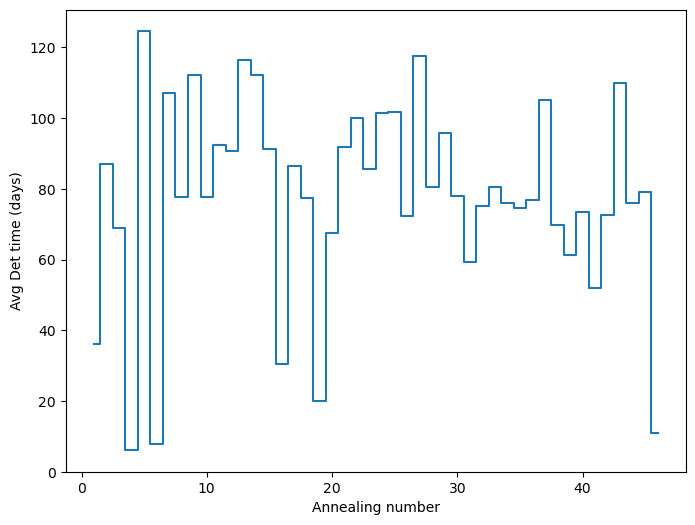

In [34]:
# init_sav_he = readsav('/Users/tbastro/SPI_analysis/BACKGROUND/spi_init_saves_HE.sav')
# init_sav_he['det_time_ann'].shape
init_sav_ann = readsav('/Users/tbastro/SPI_analysis/BACKGROUND/spi_init_saves_ann.sav')
avg_ann_time = init_sav_ann['det_time_ann'].mean(axis=1)
fig, ax=plt.subplots(1,1,figsize=(8,6))
ax.step(x=np.arange(1,len(avg_ann_time)+1), y=avg_ann_time/(3600*24), where='mid')
ax.set_ylabel('Avg Det time (days)')
ax.set_xlabel('Annealing number')
ax.set_ylim(0)